In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

display(Markdown("## 📊 DATASET 3: ONLINE RETAIL II (UCI)"))

df3 = pd.read_csv(
    r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\raw\online_retail_ii\online_retail_II.csv",
    encoding='latin1',
    low_memory=False
)

print("Shape:", df3.shape)
df3.head()

## 📊 DATASET 3: ONLINE RETAIL II (UCI)

Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [15]:
display(Markdown("### 🔍 Step 1: Data Types & Structure"))
df3.info()

### 🔍 Step 1: Data Types & Structure

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [16]:
display(Markdown("### ⚠️ Step 2: Missing Values Check"))
print(df3.isnull().sum())

### ⚠️ Step 2: Missing Values Check

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [17]:
display(Markdown("### 🔁 Step 3: Duplicate Check"))
print("Duplicate rows:", df3.duplicated().sum())

### 🔁 Step 3: Duplicate Check

Duplicate rows: 34335


In [18]:
display(Markdown("### 📈 Step 4: Summary Statistics"))
df3.describe()

### 📈 Step 4: Summary Statistics

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [19]:
display(Markdown("### ✅ Step 5: Validity Checks"))
print("Negative Quantity:", (df3['Quantity'] < 0).sum())
print("Negative Price:", (df3['Price'] < 0).sum())
print("Zero Price:", (df3['Price'] == 0).sum())
print("Date range:", df3['InvoiceDate'].min(), "to", df3['InvoiceDate'].max())
print("Unique Countries:", df3['Country'].nunique())
print("Unique Customers:", df3['Customer ID'].nunique())

### ✅ Step 5: Validity Checks

Negative Quantity: 22950
Negative Price: 5
Zero Price: 6202
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique Countries: 43
Unique Customers: 5942


### 🎨 Chart 1: Top 10 Countries by Transactions

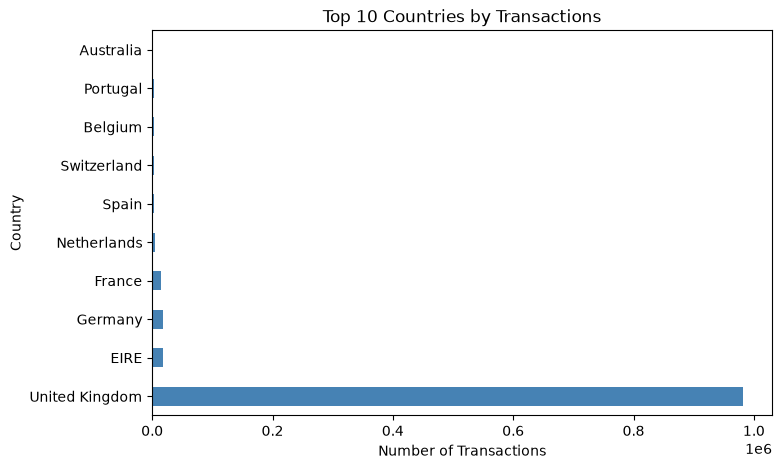

In [20]:
display(Markdown("### 🎨 Chart 1: Top 10 Countries by Transactions"))

plt.figure(figsize=(8,5))
df3['Country'].value_counts().head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Countries by Transactions')
plt.xlabel('Number of Transactions')
plt.show()

### 🎨 Chart 2: Price Distribution (under £50)

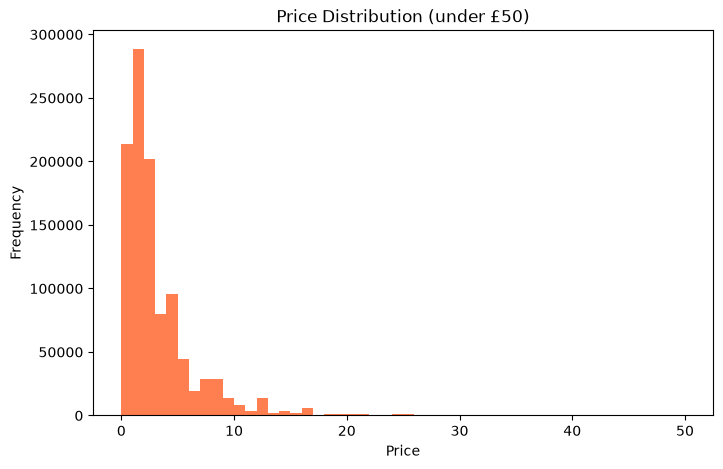

In [21]:
display(Markdown("### 🎨 Chart 2: Price Distribution (under £50)"))

plt.figure(figsize=(8,5))
plt.hist(df3['Price'], bins=50, range=(0,50), color='coral')
plt.title('Price Distribution (under £50)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

### 🎨 Chart 3: Monthly Quantity Sold Trend

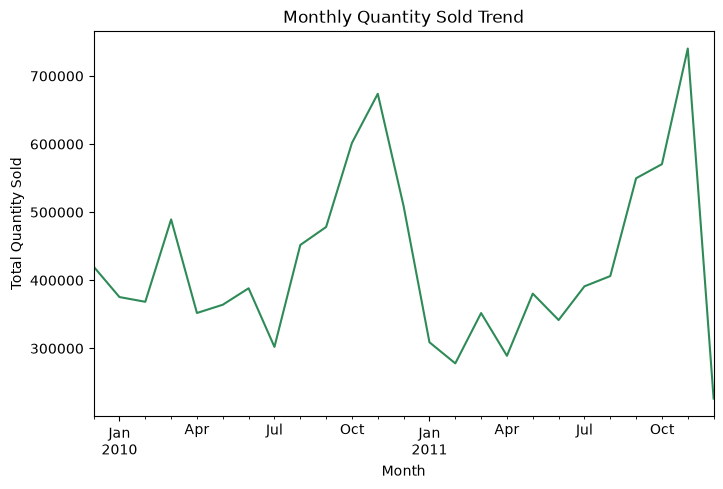

In [22]:
display(Markdown("### 🎨 Chart 3: Monthly Quantity Sold Trend"))

df3['InvoiceDate'] = pd.to_datetime(df3['InvoiceDate'])
plt.figure(figsize=(8,5))
df3.set_index('InvoiceDate').resample('ME')['Quantity'].sum().plot(color='seagreen')
plt.title('Monthly Quantity Sold Trend')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.show()

### 🎨 Chart 4: Top 10 Best-Selling Products

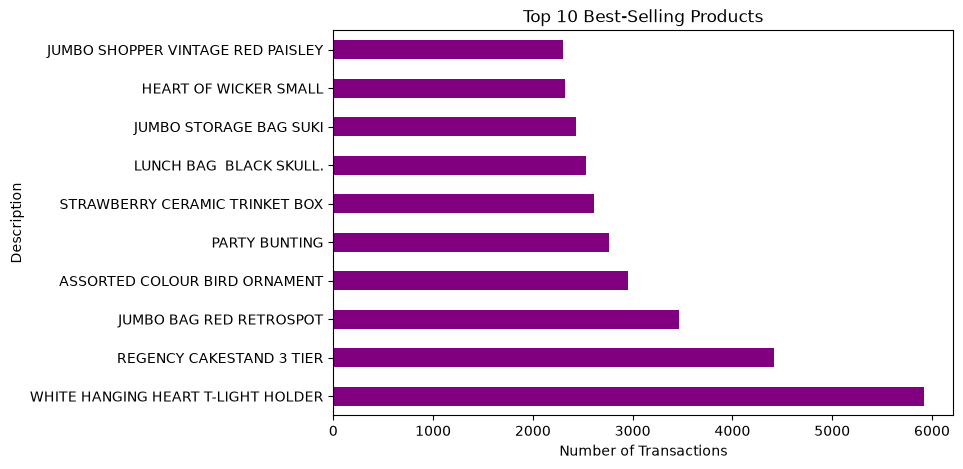

In [23]:
display(Markdown("### 🎨 Chart 4: Top 10 Best-Selling Products"))

plt.figure(figsize=(8,5))
df3['Description'].value_counts().head(10).plot(kind='barh', color='purple')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Number of Transactions')
plt.show()

### 🎨 Step 6: Visual EDA

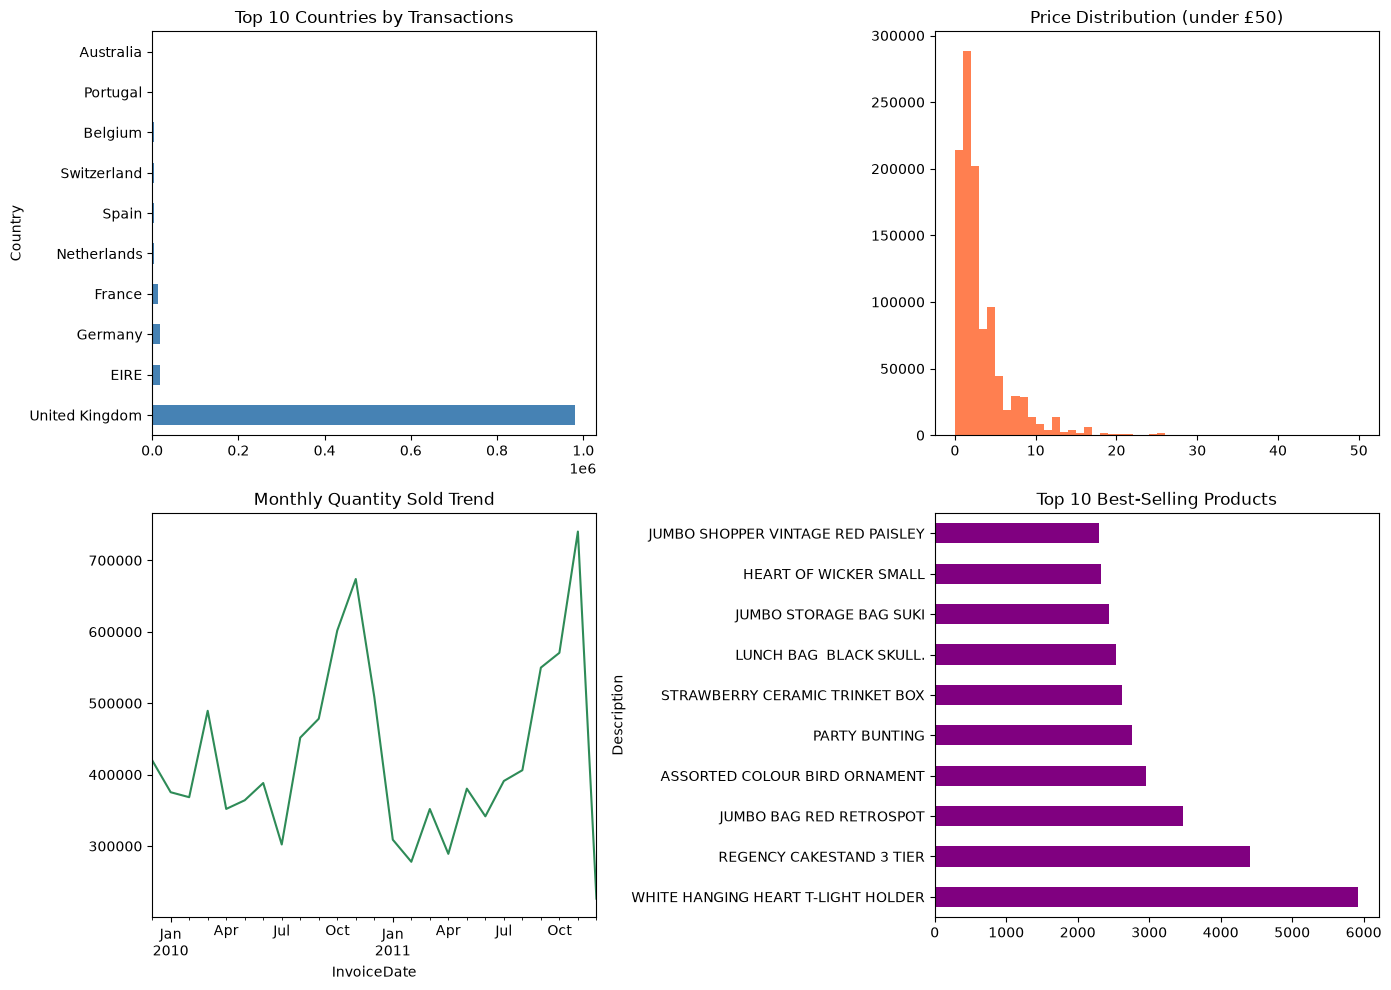

In [24]:
display(Markdown("### 🎨 Step 6: Visual EDA"))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df3['Country'].value_counts().head(10).plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top 10 Countries by Transactions')

axes[0,1].hist(df3['Price'], bins=50, range=(0,50), color='coral')
axes[0,1].set_title('Price Distribution (under £50)')

df3.set_index('InvoiceDate').resample('ME')['Quantity'].sum().plot(ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Monthly Quantity Sold Trend')

df3['Description'].value_counts().head(10).plot(kind='barh', ax=axes[1,1], color='purple')
axes[1,1].set_title('Top 10 Best-Selling Products')

plt.tight_layout()
plt.show()

In [25]:
display(Markdown("### 🧹 Step 6: Data Cleaning"))

df3 = df3.drop_duplicates()
df3 = df3[df3['Price'] >= 0]
df3 = df3[~df3['Invoice'].astype(str).str.startswith('C')]
df3 = df3[df3['Price'] > 0]
df3 = df3.dropna(subset=['Description'])
df3['InvoiceDate'] = pd.to_datetime(df3['InvoiceDate'])
df3.columns = df3.columns.str.lower().str.replace(' ', '_')

print("Shape after cleaning:", df3.shape)
print("\nMissing values now:")
print(df3.isnull().sum())
print("\nNegative quantity remaining:", (df3['quantity'] < 0).sum())

### 🧹 Step 6: Data Cleaning

Shape after cleaning: (1007913, 8)

Missing values now:
invoice             0
stockcode           0
description         0
quantity            0
invoicedate         0
price               0
customer_id    228488
country             0
dtype: int64

Negative quantity remaining: 0


In [26]:
display(Markdown("### 💾 Step 7: Save Cleaned Dataset"))

df3.to_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\processed_data\online_retail_ii_clean.csv", index=False)

print("Saved successfully!")
print("Final shape:", df3.shape)

### 💾 Step 7: Save Cleaned Dataset

Saved successfully!
Final shape: (1007913, 8)
